### Read the SNOWPACK TKG4 WY2020-WY2025 Simulations

created by Cassie Lumbrazo\
last updated: April 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tkg4'

## Put Some JIF Data info a simple dataframe to plot later

In [27]:
# create a new dataframe with field data above 
# site name = tkg4
# date = 2024-06-15, as in, June 15, 2024
# total core depth = 800 cm 
# snow-firm transition depth = 642.5 cm 

df_field_tkg4 = pd.DataFrame({
    'date': ['2024-06-07','2024-06-15'],
    'site': ['tkg4','tkg4'],
    # 'core_depth_cm': [800],
    'snow_firm_transition_depth_cm': [645, 642.5]
})

# df_field date to datetime
df_field_tkg4['date'] = pd.to_datetime(df_field_tkg4['date'])
df_field_tkg4


,date,site,snow_firm_transition_depth_cm
0,2024-06-07,tkg4,645.0
1,2024-06-15,tkg4,642.5


In [28]:
# create a new dataframe with the field data from MLD4 site 
# site name = mld4
# date = 2024-06-11, as in June 11, 2024
# total core depth = 678.5 cm

# date = 2024-06-18, as in June 18, 2024
# total core depth = 657 cm 

df_field_mld4 = pd.DataFrame({
    'date': ['2024-06-11', '2024-06-18'],
    'site': ['mld4', 'mld4'],
    'core_depth_cm': [678.5, 657]
})
df_field_mld4

,date,site,core_depth_cm
0,2024-06-11,mld4,678.5
1,2024-06-18,mld4,657.0


# Open Data and Model Simulations

## Function for Reading SMET Files 

In [29]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

## Open SNOWPACK SMet Output for WY2020-WY2025

In [30]:
ds_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2020-WY2025_heatflux_soiltemp_zero.smet")

/tmp/ipykernel_1074079/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

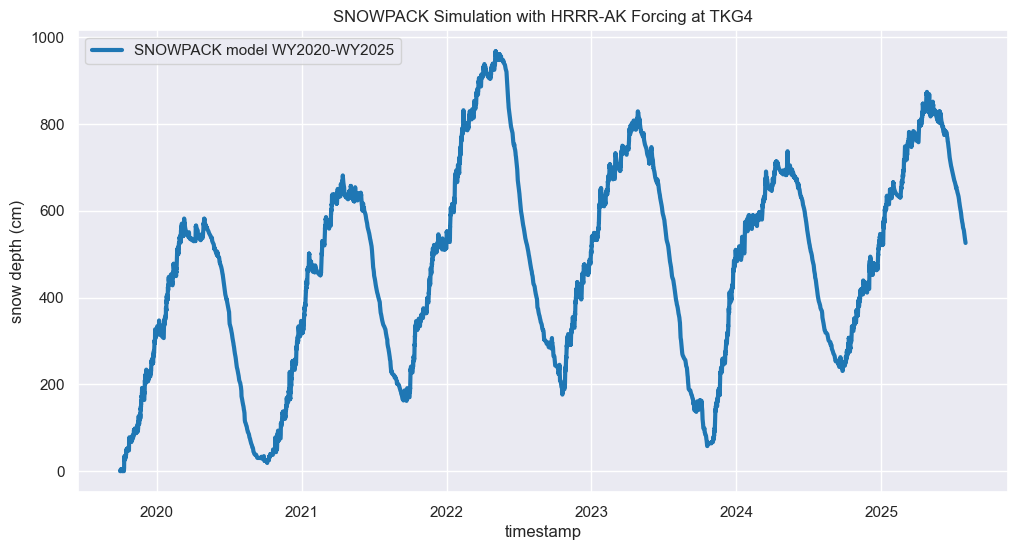

In [31]:
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at TKG4')
plt.legend(loc='upper left')

plt.ylabel('snow depth (cm)')

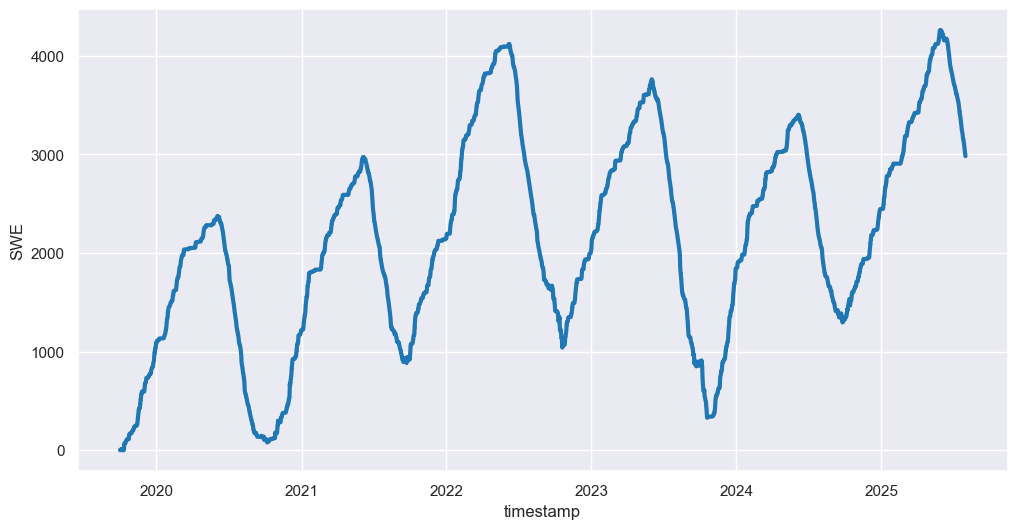

In [32]:
# plot SWE 
ds_snowpack.SWE.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue')

Text(0, 0.5, 'snow depth (cm)')

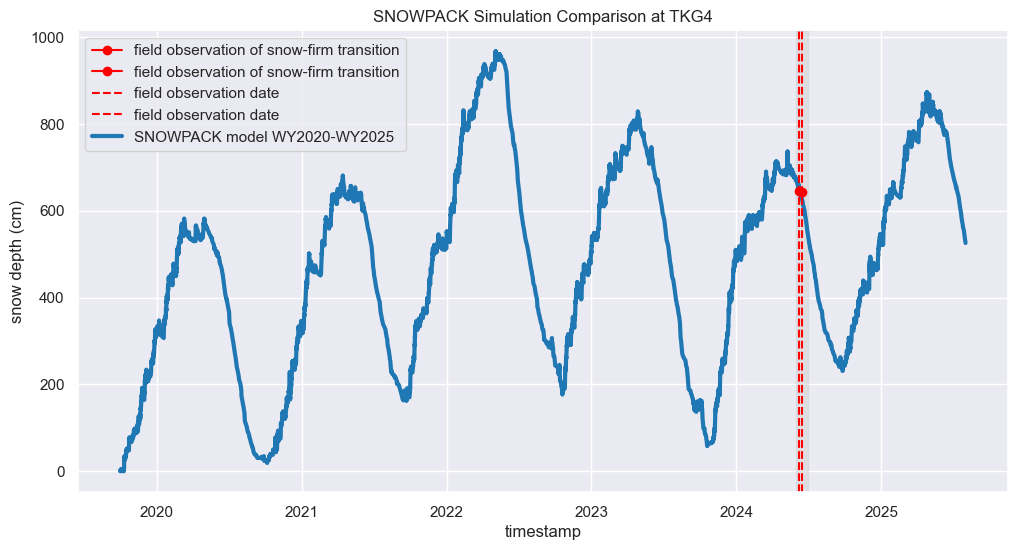

In [33]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_tkg4['date'].iloc[1], color='red', linestyle='--', label='field observation date')

# add the snow depth measurement as a red marker at the date of the field observation
# take the simulation snow depth from June 15 2024 and subtract the snow-firm transition depth to get the snow depth above the snow-firm transition, which is what we observed in the field
snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[1], method='nearest').values
# snow_depth_WY2024_above_transition = snow_depth_WY2024 - df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]
# plt.plot(df_field_tkg4['date'].iloc[0], snow_depth_WY2024_above_transition, marker='o', color='red', label='field observation of snow-firm transition')

# plot df snow-firm 
plt.plot(df_field_tkg4['date'].iloc[0], df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0], marker='o', color='red', label='field observation of snow-firm transition')
plt.plot(df_field_tkg4['date'].iloc[1], df_field_tkg4['snow_firm_transition_depth_cm'].iloc[1], marker='o', color='red', label='field observation of snow-firm transition')

plt.title('SNOWPACK Simulation Comparison at TKG4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.ylabel('snow depth (cm)')

In [34]:
# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_June_07_2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
snow_depth_on_June_15_2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[1], method='nearest').values

# print the value for the snow depth on June 15, 2024 for the WY2024 simulation
print(f"Modeled snow depth on June 07, 2024: {snow_depth_on_June_07_2024:.2f} cm")
# print the value for the firn-snow transiation depth on June 07, 2024 in df_field_tkg4
print(f"Field observation of snow-firm transition depth on June 07, 2024: {df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]:.2f} cm")

# print the value for the snow depth on June 15, 2024 for the WY2024 simulation
print(f"Modeled snow depth on June 15, 2024: {snow_depth_on_June_15_2024:.2f} cm")
# print the value for the firn-snow transiation depth on June 15, 2024 in df_field_tkg4
print(f"Field observation of snow-firm transition depth on June 15, 2024: {df_field_tkg4['snow_firm_transition_depth_cm'].iloc[1]:.2f} cm")

Modeled snow depth on June 07, 2024: 655.43 cm
Field observation of snow-firm transition depth on June 07, 2024: 645.00 cm
Modeled snow depth on June 15, 2024: 625.82 cm
Field observation of snow-firm transition depth on June 15, 2024: 642.50 cm


## Add in previous simulations to compare, 

In [11]:
ds_snowpack_WY2024_25, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2024-25_heatflux_soiltemp_zero.smet")

/tmp/ipykernel_1074079/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

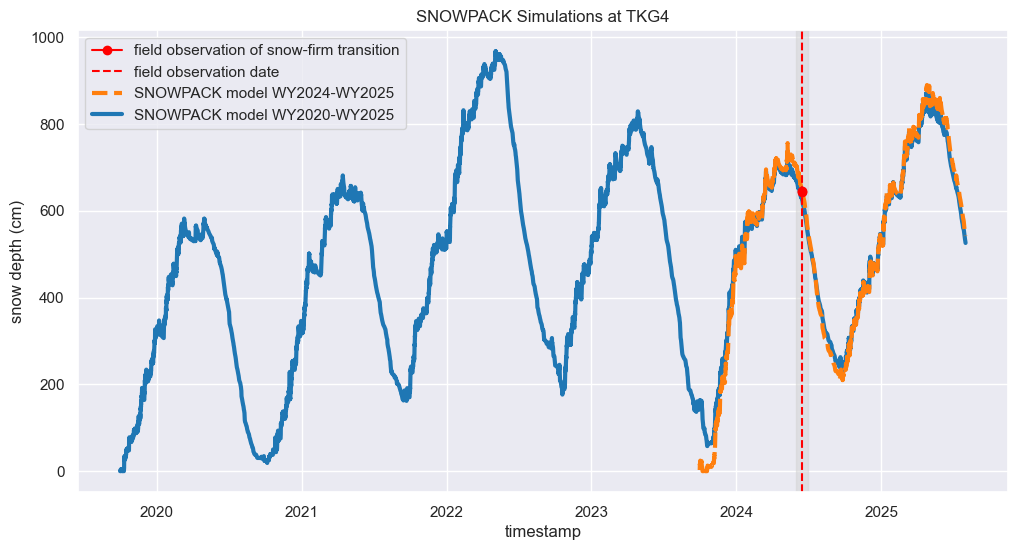

In [12]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')
ds_snowpack_WY2024_25.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')

# add the snow depth measurement as a red marker at the date of the field observation
# take the simulation snow depth from June 15 2024 and subtract the snow-firm transition depth to get the snow depth above the snow-firm transition, which is what we observed in the field
snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
# snow_depth_WY2024_above_transition = snow_depth_WY2024 - df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]
# plt.plot(df_field_tkg4['date'].iloc[0], snow_depth_WY2024_above_transition, marker='o', color='red', label='field observation of snow-firm transition')

# plot df snow-firm 
plt.plot(df_field_tkg4['date'], df_field_tkg4['snow_firm_transition_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')

plt.title('SNOWPACK Simulations at TKG4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.ylabel('snow depth (cm)')

In [35]:
# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_June_07_2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
snow_depth_on_June_07_2024_WY2024_25 = ds_snowpack_WY2024_25.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values

# print the value for the snow depth on June 07, 2024 for the WY2024 simulation
print(f"Modeled snow depth on June 07, 2024 (WY2020-WY2025): {snow_depth_on_June_07_2024:.2f} cm")
# print the value for the snow depth on June 07, 2024 for the WY2024_25 simulation
print(f"Modeled snow depth on June 07, 2024 (WY2024-WY2025): {snow_depth_on_June_07_2024_WY2024_25:.2f} cm")
# print the value for the firn-snow transiation depth on June 07, 2024 in df_field_tkg4
print(f"Field observation of snow-firm transition depth on June 07, 2024: {df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]:.2f} cm")


# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_June_15_2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[1], method='nearest').values
snow_depth_on_June_15_2024_WY2024_25 = ds_snowpack_WY2024_25.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[1], method='nearest').values

# print the value for the snow depth on June 15, 2024 for the WY2024 simulation
print(f"Modeled snow depth on June 15, 2024 (WY2020-WY2025): {snow_depth_on_June_15_2024:.2f} cm")
# print the value for the snow depth on June 15, 2024 for the WY2024_25 simulation
print(f"Modeled snow depth on June 15, 2024 (WY2024-WY2025): {snow_depth_on_June_15_2024_WY2024_25:.2f} cm")
# print the value for the firn-snow transiation depth on June 15, 2024 in df_field_tkg4
print(f"Field observation of snow-firm transition depth on June 15, 2024: {df_field_tkg4['snow_firm_transition_depth_cm'].iloc[1]:.2f} cm")

Modeled snow depth on June 07, 2024 (WY2020-WY2025): 655.43 cm
Modeled snow depth on June 07, 2024 (WY2024-WY2025): 684.64 cm
Field observation of snow-firm transition depth on June 07, 2024: 645.00 cm
Modeled snow depth on June 15, 2024 (WY2020-WY2025): 625.82 cm
Modeled snow depth on June 15, 2024 (WY2024-WY2025): 650.34 cm
Field observation of snow-firm transition depth on June 15, 2024: 642.50 cm


## Now, zero out the WY2024 and compare 

Text(0.5, 1.0, 'SNOWPACK Simulation with HRRR-AK Forcing at TKG4 Site')

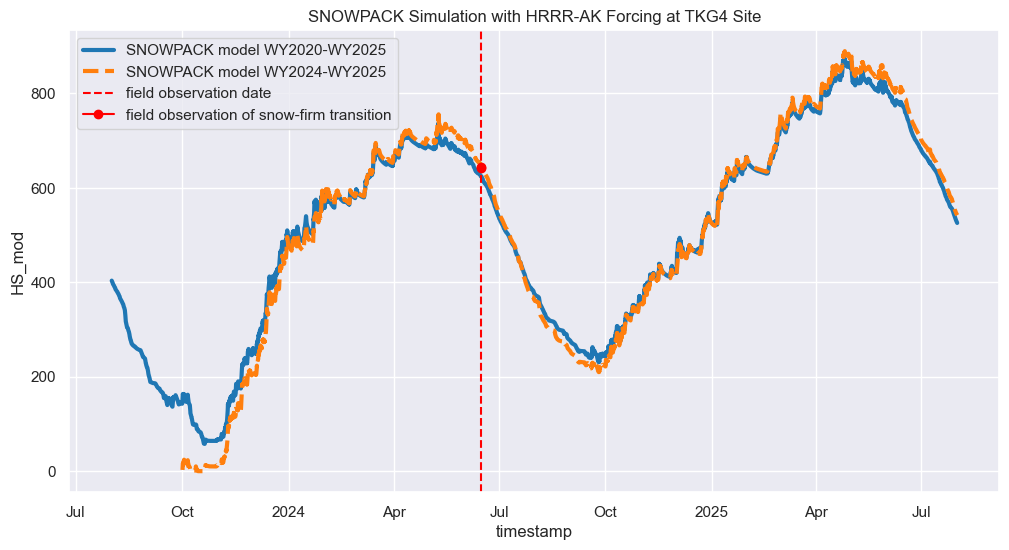

In [14]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack.HS_mod.copy(deep=True)
# now, only keep the dates between 2023-09-01 and 2024-09-01
hs_model_ds = hs_model_ds.sel(timestamp=slice('2023-08-01', '2025-09-01'))
hs_model_ds.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

ds_snowpack_WY2024_25.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')

# add the snow depth measurement as a red marker at the date of the field observation
# take the simulation snow depth from June 15 2024 and subtract the snow-firm transition depth to get the snow depth above the snow-firm transition, which is what we observed in the field
snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
# snow_depth_WY2024_above_transition = snow_depth_WY2024 - df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]
# plt.plot(df_field_tkg4['date'].iloc[0], snow_depth_WY2024_above_transition, marker='o', color='red', label='field observation of snow-firm transition')

# plot df snow-firm 
plt.plot(df_field_tkg4['date'], df_field_tkg4['snow_firm_transition_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')

plt.legend(loc='upper left')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at TKG4 Site')

Text(0.5, 1.0, 'SNOWPACK Simulations on the Juneau Icefield Site TKG4')

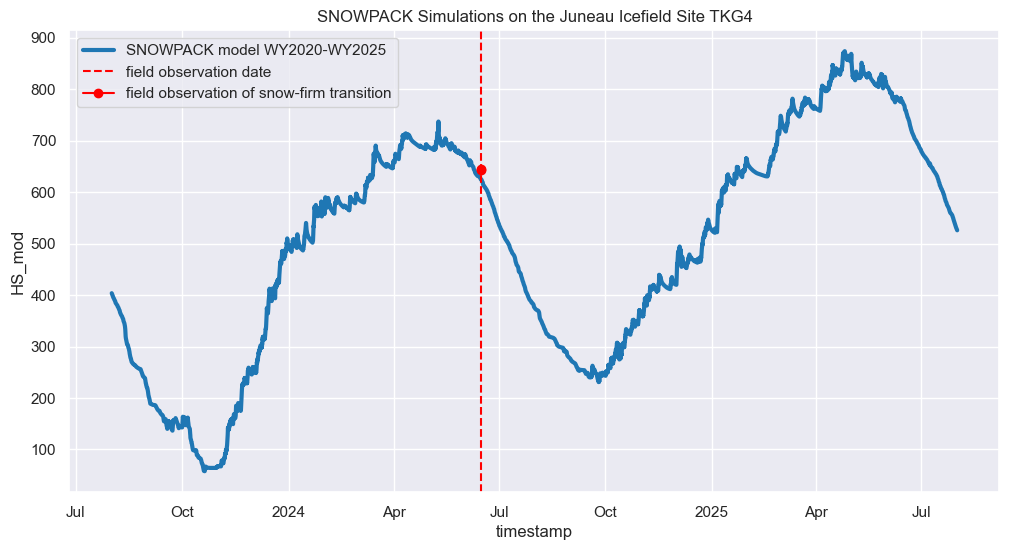

In [15]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack.HS_mod.copy(deep=True)
# now, only keep the dates between 2023-09-01 and 2024-09-01
hs_model_ds = hs_model_ds.sel(timestamp=slice('2023-08-01', '2025-09-01'))
hs_model_ds.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

# ds_snowpack_WY2024_25.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')

# add the snow depth measurement as a red marker at the date of the field observation
# take the simulation snow depth from June 15 2024 and subtract the snow-firm transition depth to get the snow depth above the snow-firm transition, which is what we observed in the field
snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
# snow_depth_WY2024_above_transition = snow_depth_WY2024 - df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]
# plt.plot(df_field_tkg4['date'].iloc[0], snow_depth_WY2024_above_transition, marker='o', color='red', label='field observation of snow-firm transition')

# plot df snow-firm 
plt.plot(df_field_tkg4['date'], df_field_tkg4['snow_firm_transition_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')

plt.legend(loc='upper left')

plt.title('SNOWPACK Simulations on the Juneau Icefield Site TKG4')

# Deliverable Figures

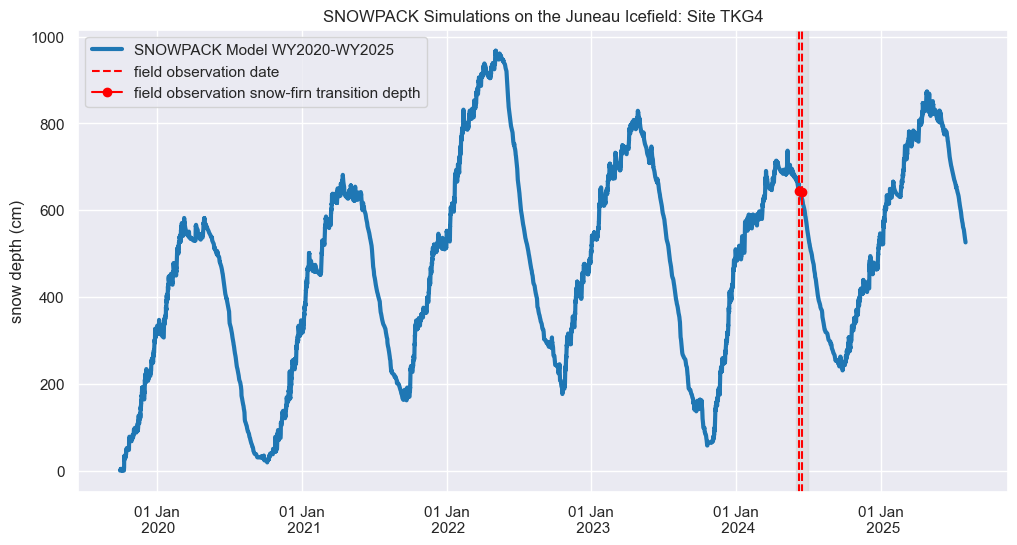

In [40]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.HS_mod.plot(label = 'SNOWPACK Model WY2020-WY2025', linewidth = 3, color='tab:blue')
# ds_snowpack_WY2024_25.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_tkg4['date'].iloc[1], color='red', linestyle='--', label='')

# add the snow depth measurement as a red marker at the date of the field observation
# take the simulation snow depth from June 15 2024 and subtract the snow-firn transition depth to get the snow depth above the snow-firn transition, which is what we observed in the field
snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[1], method='nearest').values
# snow_depth_WY2024_above_transition = snow_depth_WY2024 - df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]
# plt.plot(df_field_tkg4['date'].iloc[0], snow_depth_WY2024_above_transition, marker='o', color='red', label='field observation of snow-firn transition')

# plot df snow-firn 
plt.plot(df_field_tkg4['date'], df_field_tkg4['snow_firm_transition_depth_cm'], marker='o', color='red', label='field observation snow-firn transition depth')

plt.title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::1], labels[::1])
# plt.legend('upper left', labels=labels)
plt.ylabel('snow depth (cm)')

# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.show()

And SWE, 

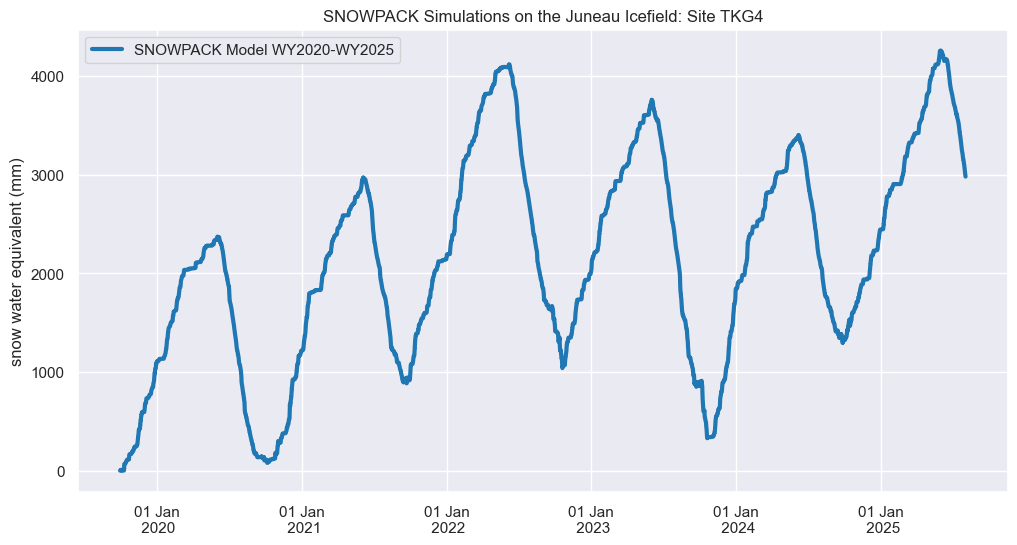

In [17]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.SWE.plot(label = 'SNOWPACK Model WY2020-WY2025', linewidth = 3, color='tab:blue')
# ds_snowpack_WY2024_25.SWE.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

plt.title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::1], labels[::1])
# plt.legend('upper left', labels=labels)
plt.ylabel('snow water equivalent (mm)')

# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.show()

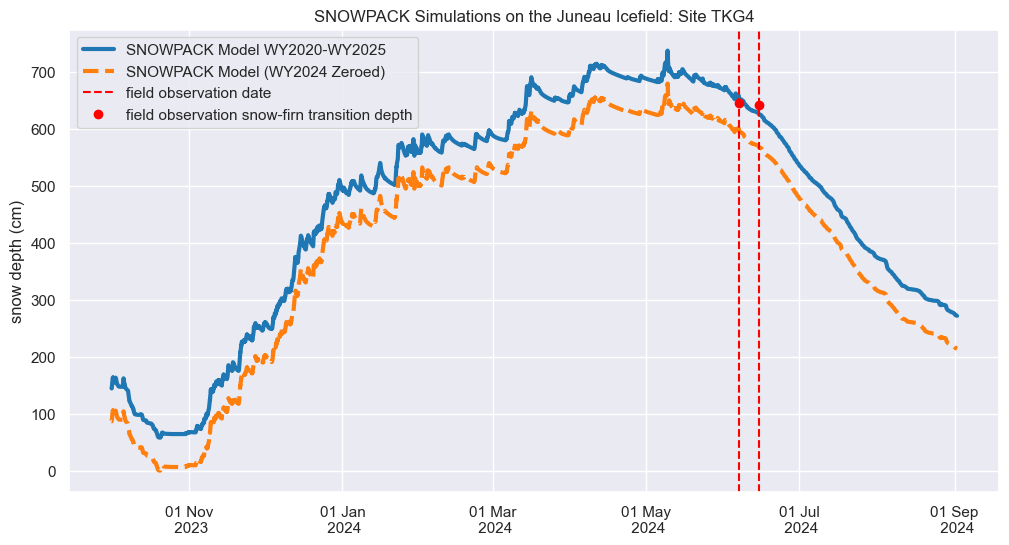

In [45]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack.HS_mod.sel(timestamp=slice('2023-10-01', '2024-09-01')).copy(deep=True)
hs_model_ds.plot(label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

# plot a zeroed-out WY2024 line so the minimum snow depth starts at zero
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')
hs_model_zeroed.plot(label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_tkg4['date'].iloc[1], color='red', linestyle='--', label='')

# add the snow depth measurement as a red marker at the date of the field observation
# take the simulation snow depth from June 15 2024 and subtract the snow-firn transition depth to get the snow depth above the snow-firn transition, which is what we observed in the field
# snow_depth_WY2024 = ds_snowpack.HS_mod.sel(timestamp=df_field_tkg4['date'].iloc[0], method='nearest').values
# snow_depth_WY2024_above_transition = snow_depth_WY2024 - df_field_tkg4['snow_firm_transition_depth_cm'].iloc[0]
# plt.plot(df_field_tkg4['date'].iloc[0], snow_depth_WY2024_above_transition, marker='o', color='red', label='field observation of snow-firn transition')

# plot df snow-firn 
plt.plot(df_field_tkg4['date'], df_field_tkg4['snow_firm_transition_depth_cm'], marker='o', linestyle='', color='red', label='field observation snow-firn transition depth')

plt.legend(loc='upper left')

plt.title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')

# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.ylabel('snow depth (cm)')
plt.show()

In [19]:
df_field_tkg4

,date,site,snow_firm_transition_depth_cm
0,2024-06-15,tkg4,645.0
1,2024-06-15,tkg4,642.5


In [48]:
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0,1]:
    obs_date = df_field_tkg4['date'].iloc[i]
    field_depth = df_field_tkg4['snow_firm_transition_depth_cm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field core depth: {field_depth:.0f} cm")
    print(f"  Blue WY2024 model value: {blue_value:.0f} cm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.0f} cm")
    # print the modeled vs observated difference (%)
    if field_depth != 0:
        blue_diff_pct = (blue_value - field_depth) / field_depth * 100
        orange_diff_pct = (orange_value - field_depth) / field_depth * 100
        print(f"  Blue WY2024 model difference from observation: {blue_diff_pct:.0f}%")
        print(f"  Orange WY2024 zeroed model difference from observation: {orange_diff_pct:.0f}%")
    print('')

Observation 1 date: 2024-06-07
  Field core depth: 645 cm
  Blue WY2024 model value: 655 cm
  Orange WY2024 zeroed model value: 598 cm
  Blue WY2024 model difference from observation: 2%
  Orange WY2024 zeroed model difference from observation: -7%

Observation 2 date: 2024-06-15
  Field core depth: 642 cm
  Blue WY2024 model value: 626 cm
  Orange WY2024 zeroed model value: 568 cm
  Blue WY2024 model difference from observation: -3%
  Orange WY2024 zeroed model difference from observation: -12%



And, add SWE 

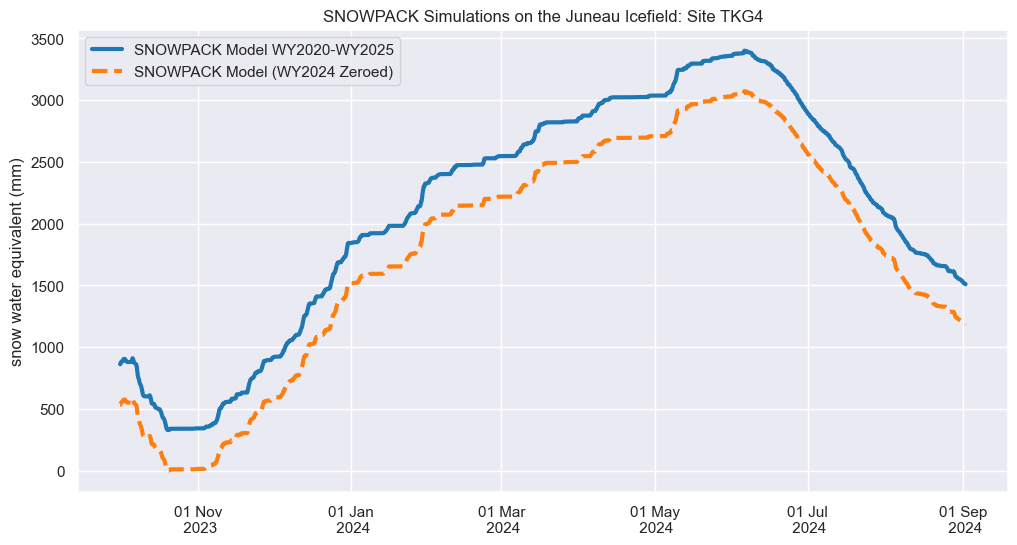

In [21]:
# we want to focus on WY2024
# so let's remove all the data before 

swe_model_ds = ds_snowpack.SWE.sel(timestamp=slice('2023-10-01', '2024-09-01')).copy(deep=True)
swe_model_ds.plot(label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

# plot a zeroed-out WY2024 line so the minimum snow depth starts at zero
swe_model_zeroed = swe_model_ds - swe_model_ds.min(dim='timestamp')
swe_model_zeroed.plot(label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

plt.legend(loc='upper left')

plt.title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')

# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.ylabel('snow water equivalent (mm)')
plt.show()

### Subplot with snow depth and swe together

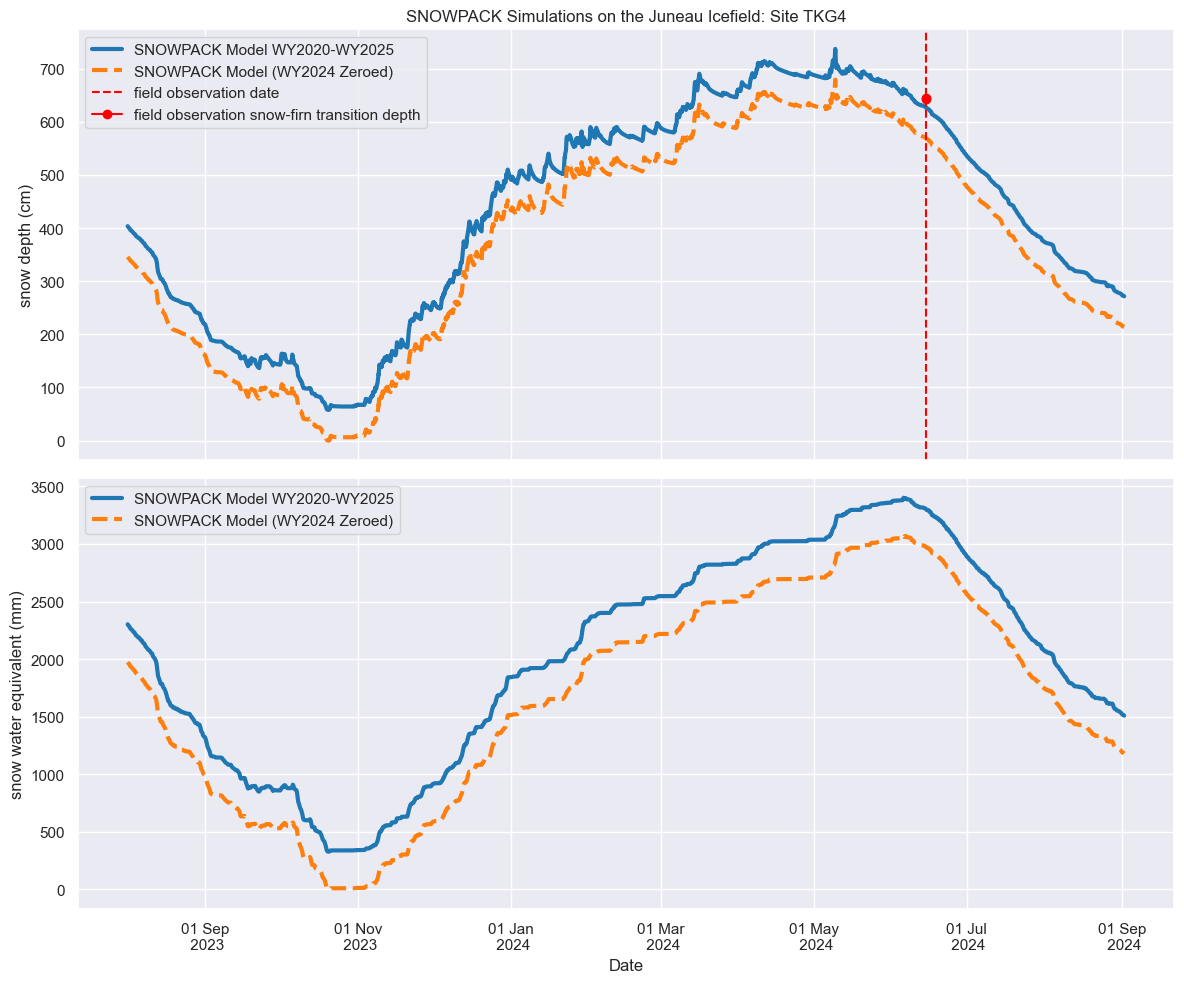

In [22]:
# combined subplot of snow depth and SWE for WY2024
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# top: snow depth
hs_model_ds = ds_snowpack.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_ds.plot(ax=axes[0], label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')
hs_model_zeroed.plot(ax=axes[0], label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

axes[0].axvline(df_field_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[0].plot(df_field_tkg4['date'], df_field_tkg4['snow_firm_transition_depth_cm'], marker='o', color='red', label='field observation snow-firn transition depth')

axes[0].legend(loc='upper left')
axes[0].set_title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')
axes[0].set_xlabel('')
axes[0].set_ylabel('snow depth (cm)')
axes[0].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))

# bottom: SWE
swe_model_ds = ds_snowpack.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_model_ds.plot(ax=axes[1], label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

swe_model_zeroed = swe_model_ds - swe_model_ds.min(dim='timestamp')
swe_model_zeroed.plot(ax=axes[1], label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

axes[1].legend(loc='upper left')
# axes[1].set_title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')
axes[1].set_ylabel('snow water equivalent (mm)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))
for label in axes[1].get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')

plt.tight_layout()
plt.show()
